In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
import torch

In [4]:
for i in range(torch.cuda.device_count()):
   print(f"{i}:", torch.cuda.get_device_properties(i).name)

0: Tesla P100-PCIE-16GB
1: Tesla P100-PCIE-16GB


In [5]:
torch.cuda.set_device("cuda:1")

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
if device.startswith("cuda"):
    print(torch.cuda.get_device_name(device))

Tesla P100-PCIE-16GB


In [7]:
from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime

In [8]:
from src import utils
from src.utils import Logger, same_seeds, load_config
from src.loader import get_dataloader
from main_unlab_unet import get_experiment_dir
from src.SlimUNETR.SlimUNETR import SlimUNETR
from monai.networks.nets import UNet

from accelerate import Accelerator

In [9]:
config, data_flag, is_HepaticVessel = load_config()
# config.trainer.batch_size = 3
data_flag

'aneurysms'

In [10]:
from src.unet3d.model import UNet3D, ResidualUNet3D


same_seeds(config.trainer.seed)

model_r = SlimUNETR(**config.slim_unetr)
# model = UNet(**config.slim_unetr)
# model = ResidualUNet3D(in_channels=1, out_channels=1, f_maps=8, num_levels=4, dropout_prob=0.3)

# model = ResidualUNet3D(
#     in_channels=1, 
#     out_channels=1, 
#     f_maps=4, 
#     num_groups=4, 
#     num_levels=3, 
#     dropout_prob=0.3
# )

model_r.to(device)
image_size = config.trainer.image_size

train_loader, val_loader, unlab_loader = get_dataloader(config, data_flag, needs_unlab=True)

In [11]:
base_exp_path_save = get_experiment_dir(config, data_flag, root="model_store", model='')

In [86]:
model_r, starting_epoch, step, val_step = utils.resume_train_state(
    model_r, base_exp_path_save, train_loader, epoch=-1
)
print("Resuming training from epoch {}".format(starting_epoch))

base_path: d:\sandbox\medical\Slim-UNETR\model_store\aneurysms_unlab_stages_with_tflab_selec\seed42\epoch400\use_tfFalse\ims_128\batch_size_8\rot_prob0.7_rot_angle0.6283\lrelu_split_new_class_GDFL_g2.0_fr08_fw080915
try to load d:\sandbox\medical\Slim-UNETR\model_store\aneurysms_unlab_stages_with_tflab_selec\seed42\epoch400\use_tfFalse\ims_128\batch_size_8\rot_prob0.7_rot_angle0.6283\lrelu_split_new_class_GDFL_g2.0_fr08_fw080915\epoch_399 train stage
Successfully loaded the training model！
Load state training success ！Start from 400 epoch
Resuming training from epoch 400


In [12]:
for i, image_batch in enumerate(tqdm(train_loader)):
    break

  0%|          | 0/39 [00:00<?, ?it/s]

In [13]:
image = image_batch["image"].to(device)
label = image_batch["label"]

In [14]:
import torchinfo

torchinfo.summary(model_r, input_data=image.to(device))

Layer (type:depth-idx)                                       Output Shape              Param #
SlimUNETR                                                    [4, 1, 128, 128, 128]     --
├─Encoder: 1-1                                               [4, 64, 96]               6,144
│    └─DepthwiseConvLayer: 2-1                               [4, 12, 32, 32, 32]       --
│    │    └─Conv3d: 3-1                                      [4, 12, 32, 32, 32]       780
│    │    └─GroupNorm: 3-2                                   [4, 12, 32, 32, 32]       24
│    └─Sequential: 2-2                                       [4, 12, 32, 32, 32]       --
│    │    └─Block: 3-3                                       [4, 12, 32, 32, 32]       4,992
│    └─DepthwiseConvLayer: 2-3                               [4, 32, 16, 16, 16]       --
│    │    └─Conv3d: 3-4                                      [4, 32, 16, 16, 16]       3,104
│    │    └─GroupNorm: 3-5                                   [4, 32, 16, 16, 16]     

In [67]:
from src.unet3d.model import UNet3D, ResidualUNet3D

model_u = UNet3D(in_channels=1, out_channels=1, f_maps=16, num_groups=4, num_levels=4, dropout_prob=0.3).cuda()
model_r = ResidualUNet3D(in_channels=1, out_channels=1, f_maps=8, num_groups=4, num_levels=3, dropout_prob=0.3).cuda()

In [134]:
import numpy as np
import torch.nn as nn

def initialize_weights(model):
    # Initializes weights according to the DCGAN paper
    for m in model.modules():
        if isinstance(m, (nn.Conv3d, nn.ConvTranspose3d, nn.BatchNorm3d)):
            nn.init.normal_(m.weight.data, 0.0, 1e-10)
            if m.bias is not None:
                nn.init.zeros_(m.bias.data)


initialize_weights(model_r)

In [31]:
torchinfo.summary(model_r, input_data=image.to(device))

Layer (type:depth-idx)                                       Output Shape              Param #
SlimUNETR                                                    [4, 1, 128, 128, 128]     --
├─Encoder: 1-1                                               [4, 64, 96]               6,144
│    └─DepthwiseConvLayer: 2-1                               [4, 12, 32, 32, 32]       --
│    │    └─Conv3d: 3-1                                      [4, 12, 32, 32, 32]       780
│    │    └─GroupNorm: 3-2                                   [4, 12, 32, 32, 32]       24
│    └─Sequential: 2-2                                       [4, 12, 32, 32, 32]       --
│    │    └─Block: 3-3                                       [4, 12, 32, 32, 32]       4,992
│    └─DepthwiseConvLayer: 2-3                               [4, 32, 16, 16, 16]       --
│    │    └─Conv3d: 3-4                                      [4, 32, 16, 16, 16]       3,104
│    │    └─GroupNorm: 3-5                                   [4, 32, 16, 16, 16]     

In [135]:
import monai
from monai.utils import ensure_tuple_rep

inference = monai.inferers.SlidingWindowInferer(
    roi_size=ensure_tuple_rep(config.trainer.image_size, dim=3),
    overlap=0.5,
    sw_device=device,
    device=device,
)

In [ ]:
# pred_2 = inference(image.to(device), model_r).to('cpu').detach().numpy()

In [136]:
pred_1 = inference(image.to(device), model_r).to('cpu').detach().numpy()

In [137]:
import numpy as np


np.linalg.norm(pred_2 - pred_1) / pred_2.size

0.0002482161216903478

In [138]:
import numpy as np
from matplotlib import pyplot as plt

from src.unlab.lab_unlab_trainer import Transforms

In [139]:
def plot_batch(image_batch, label_batch, ind = 1, slice_num = 2):
    fig, ax = plt.subplots(slice_num, 4, figsize=(40, 20))
    for i in list(range(slice_num)):
        for j in range(4):
            ax[i, j].imshow(
                image_batch[ind][0, :, :, j + i*8] + label_batch[ind][0, :, :, j + i*8] / 2, 
                cmap="gray"
            )
            ax[i, j].axis('off')
        

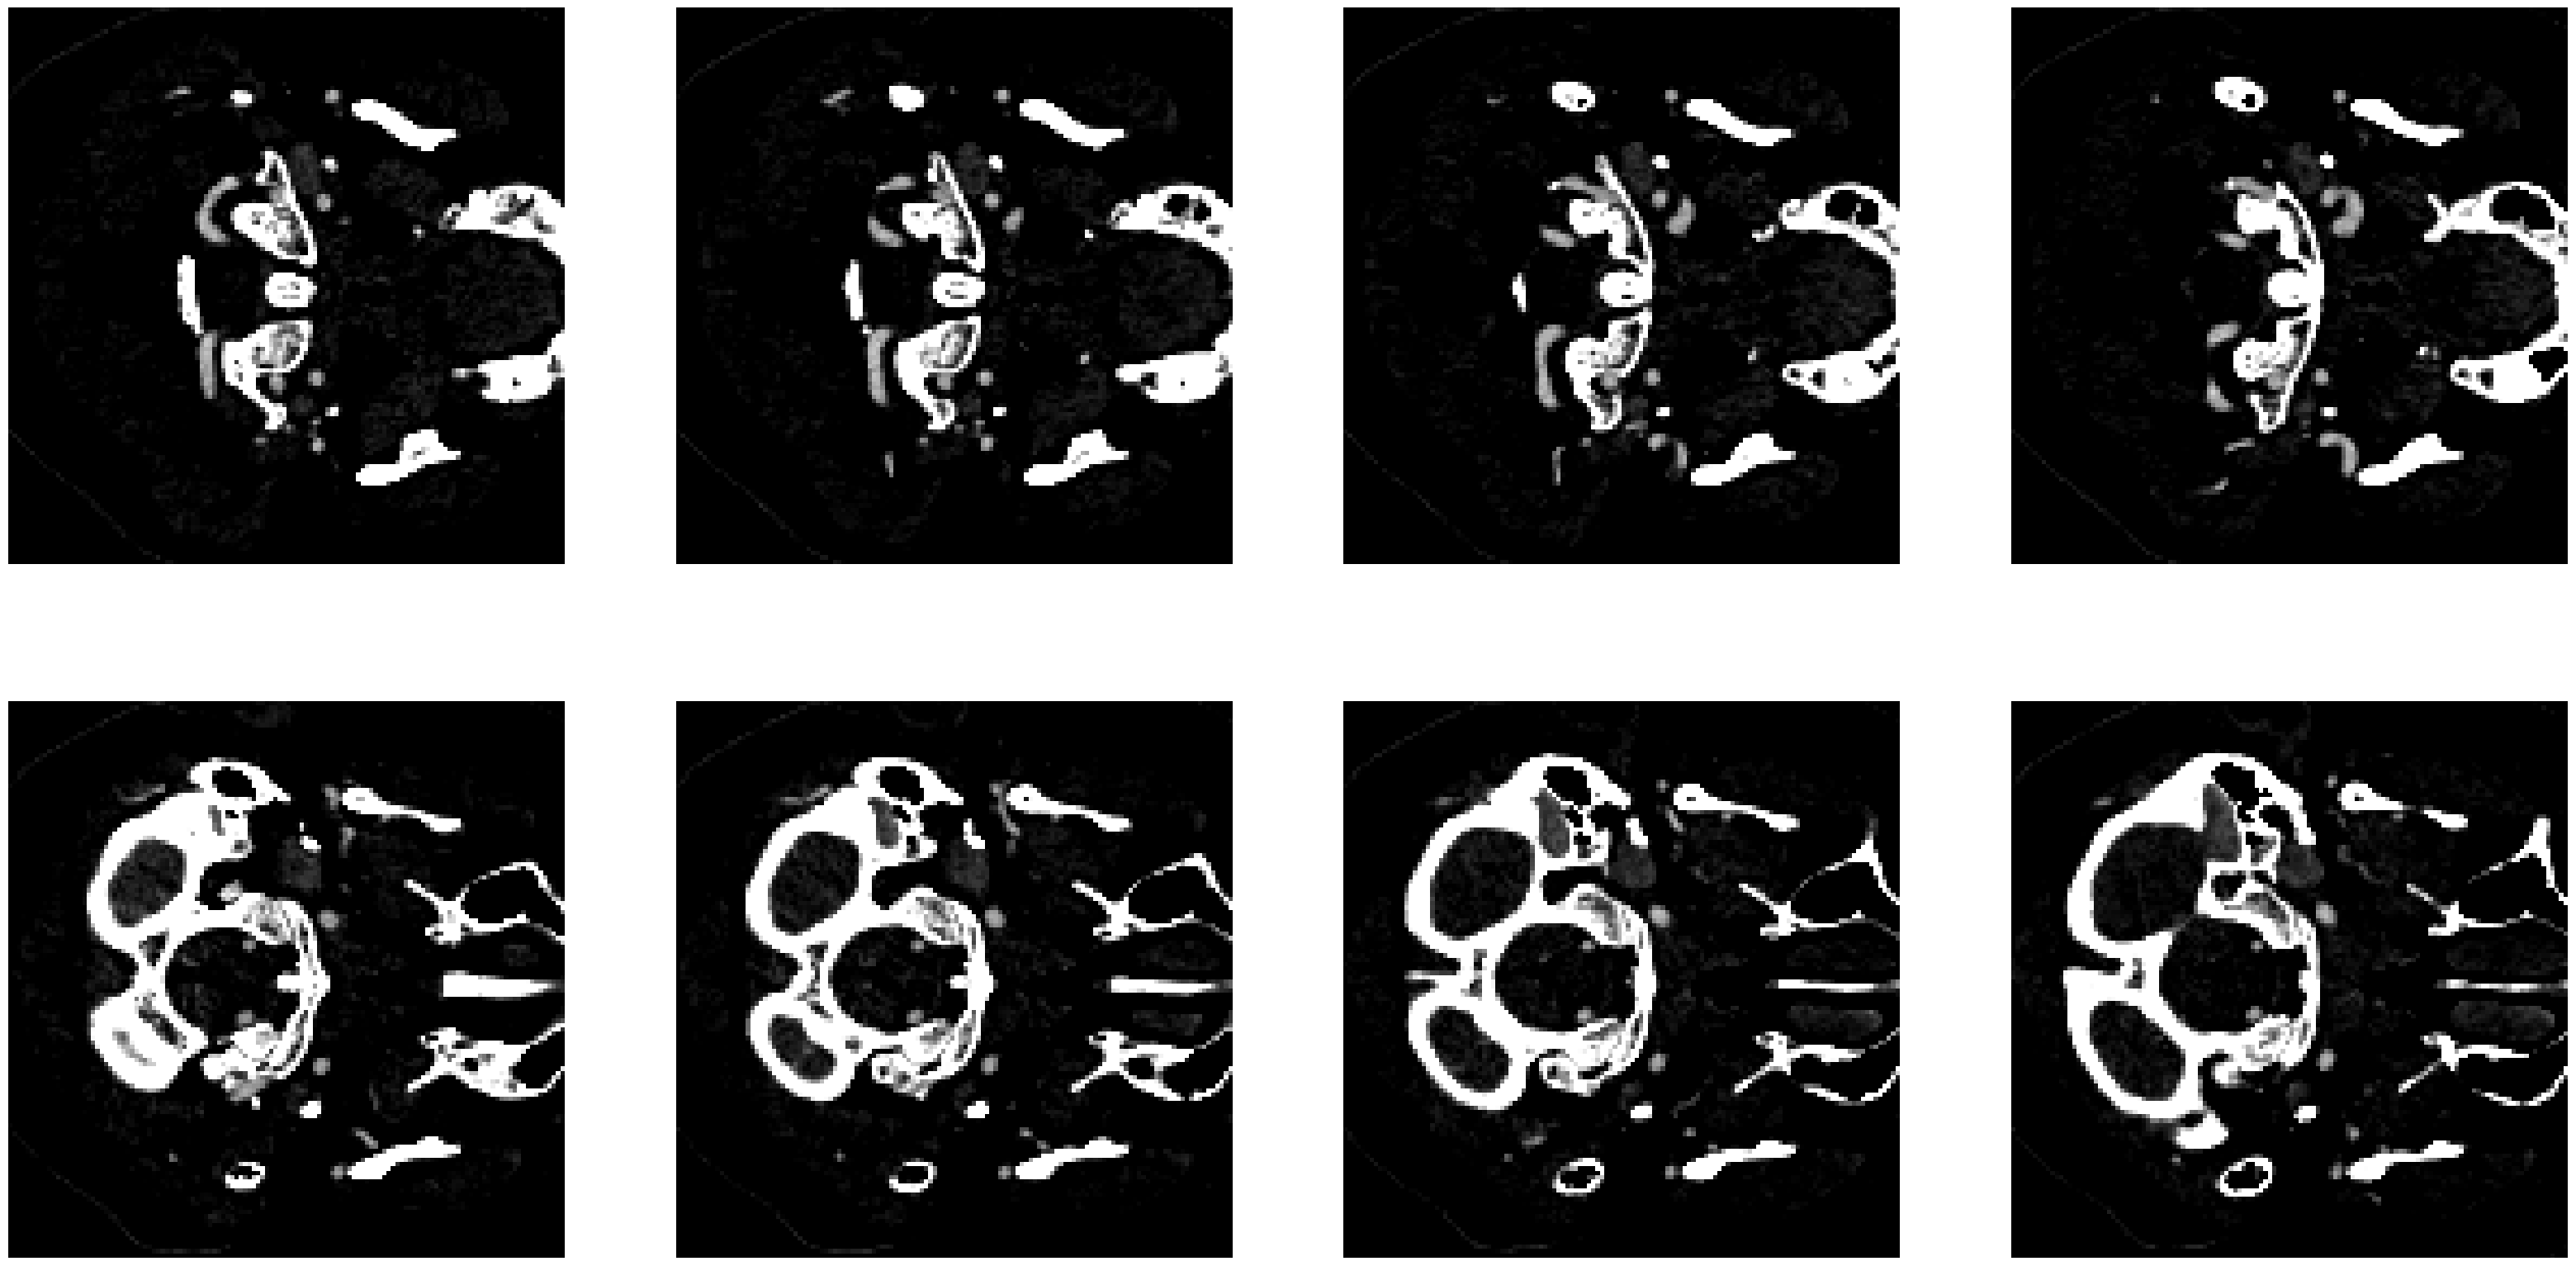

In [140]:
plot_batch(pred_1, pred_1)

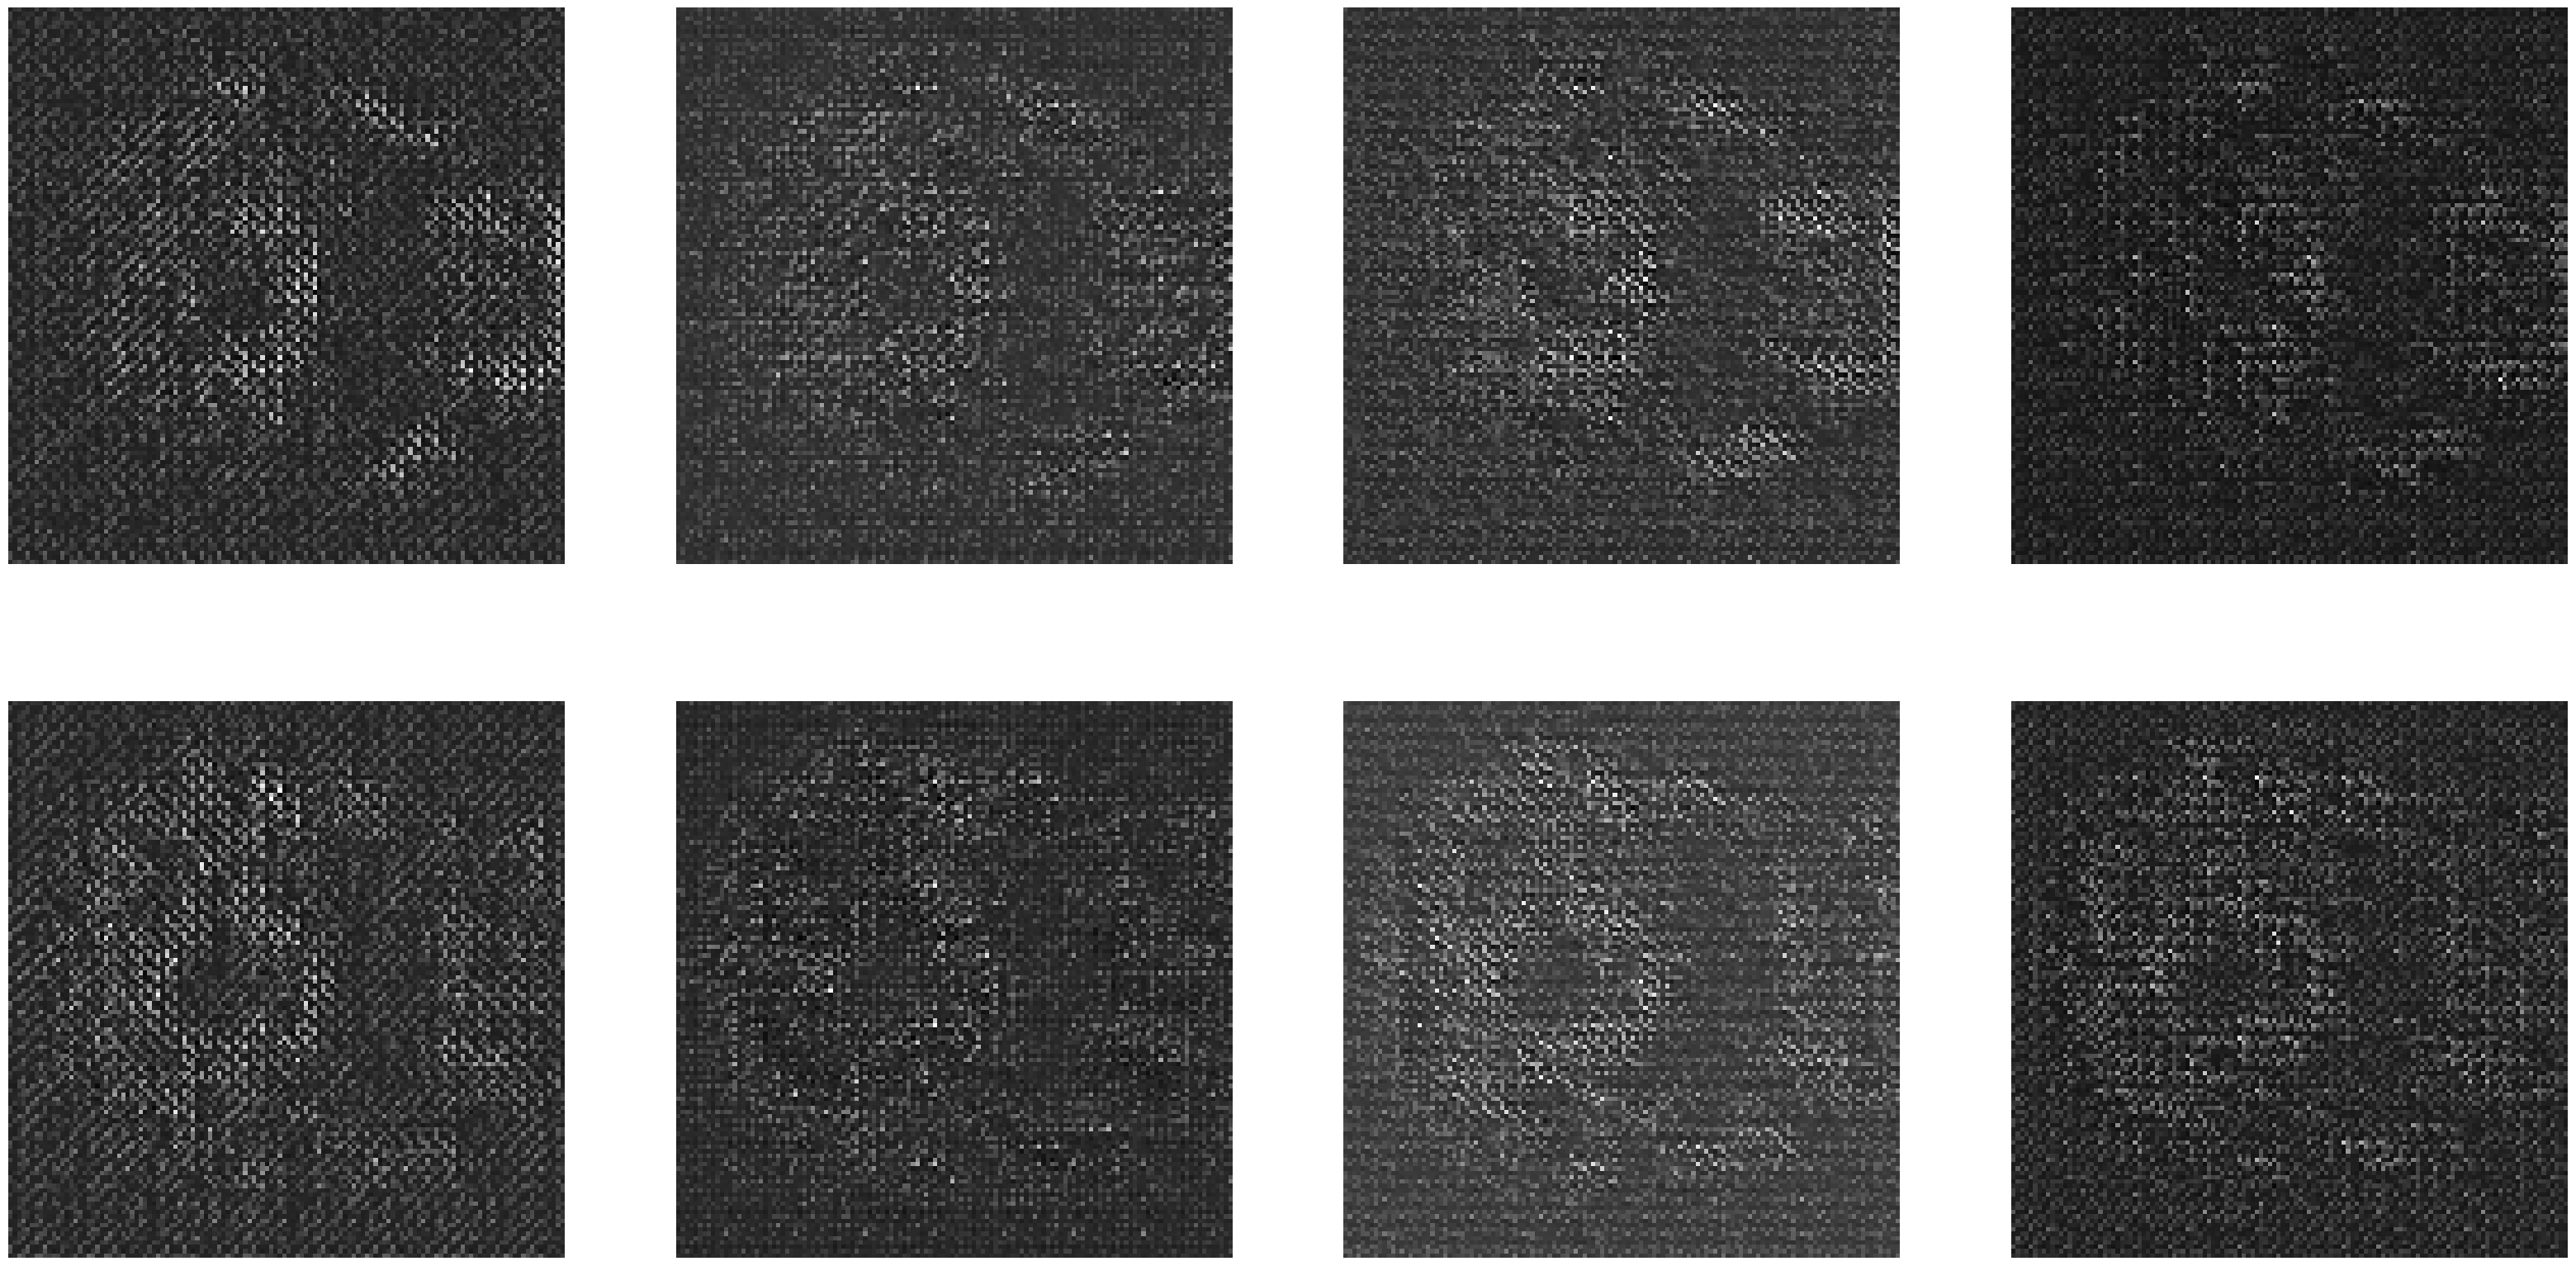

In [141]:
plot_batch(pred_2, pred_2)

In [143]:
transform = Transforms(flip_prob=0, rot_prob=1, rot_range_z=0.1*np.pi)

In [150]:
image_tf = transform(image).cpu()
label_tf = transform(pred_1, randomize=False).cpu()

In [151]:
image_tf_inv = transform.inverse(image_tf)
label_tf_inv = transform.inverse(label_tf)

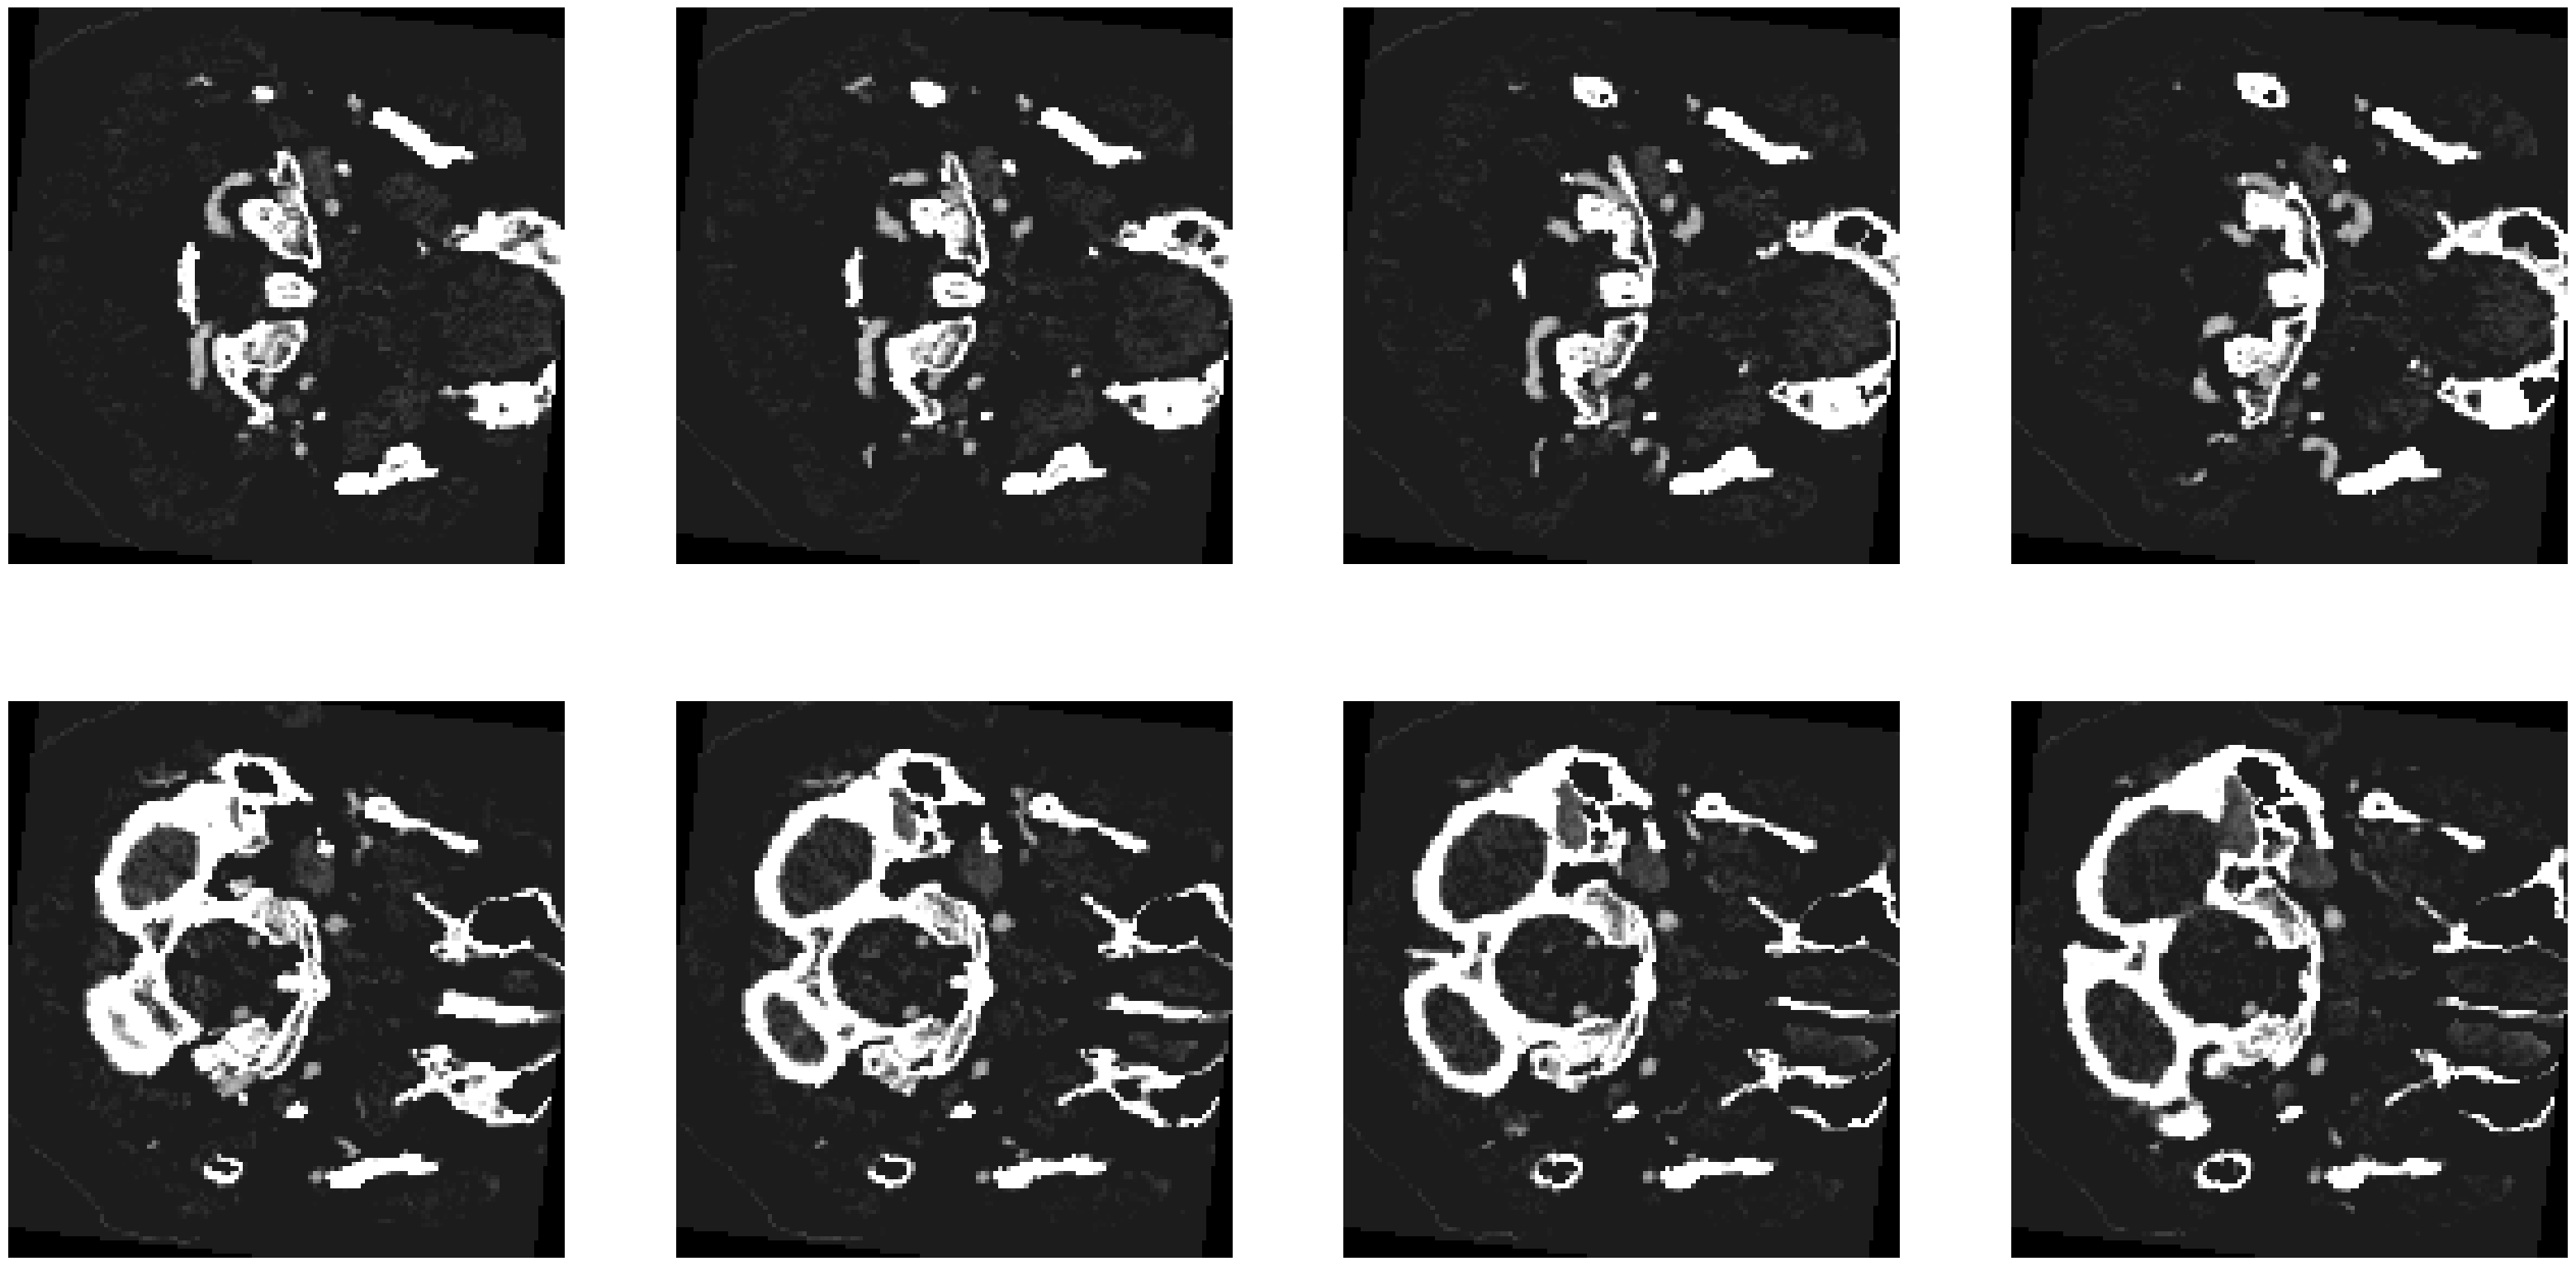

In [152]:
plot_batch(image_tf, label_tf)

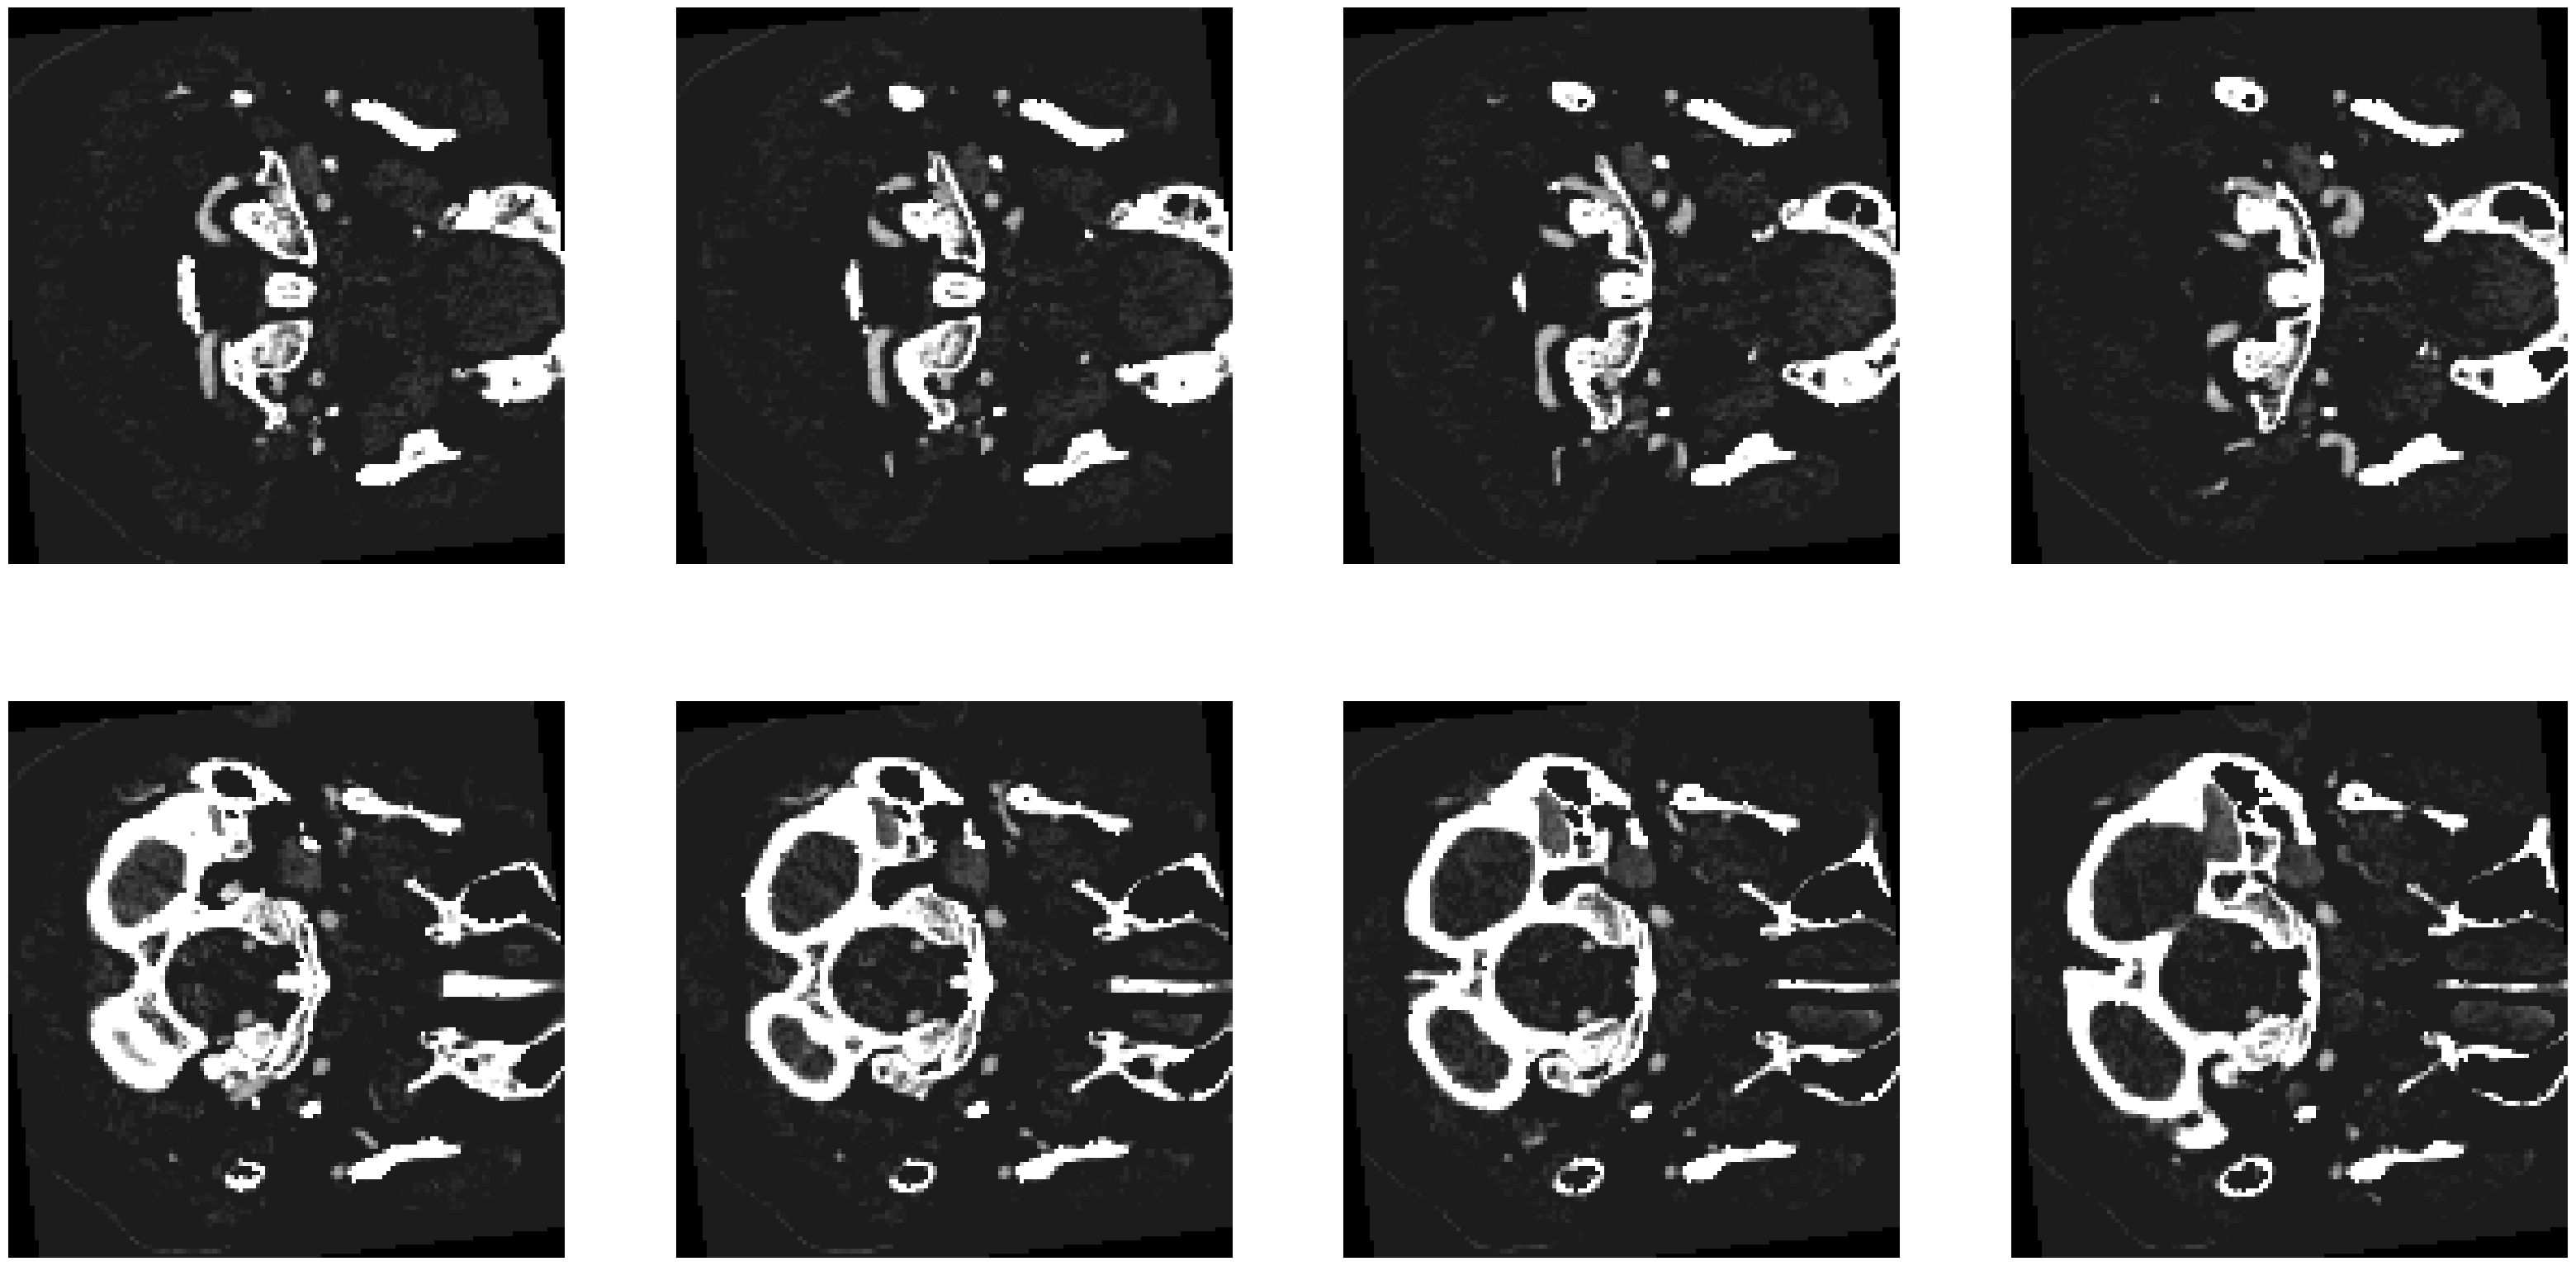

In [153]:
plot_batch(image_tf_inv, label_tf_inv)

In [154]:
import monai

In [155]:
post_trans = monai.transforms.Compose(
    [
        monai.transforms.Activations(sigmoid=True),
        monai.transforms.AsDiscrete(threshold=0.5),
    ]
)

In [ ]:
class Trainer:

    def __init__(
        self,
        model,
        train_loader,
        cfg,
    ):

        self.model = model
        
        self.train_loader = train_loader
        self.unlab_loader = unlab_loader

        self.transforms = Transforms(
            rot_prob=cfg.rot_prob,
            flip_prob=cfg.flip_prob,
            rot_range_z=cfg.rot_angle,
            final_image_size=cfg.image_size
        )
        self.unlab_weight = cfg.unlab_weight

    def train_labeled_one_epoch(
        self,
        use_transform: bool
    ):
        device = next(self.model.parameters()).device
        self.model.train()
        for i, image_batch in enumerate(tqdm(self.train_loader)):
            image = image_batch["image"].to(device)
            label = image_batch["label"].to(device)

            logits = self.model(image)
            plot_batch(
                image.cpu().numpy(), 
                label.cpu().numpy()
            )

            if use_transform:
                image_tf = self.transforms(image)
                logits_tf = self.model(image_tf)
                label_tf = self.transforms(label, randomize=False)
                plot_batch(
                    image_tf.cpu().numpy(), 
                    label_tf.cpu().numpy()
                )
                
                val_outputs = [post_trans(logit) for logit in logits_tf.detach().cpu().numpy()]
                plot_batch(
                    image_tf.cpu().numpy(), 
                    np.stack(val_outputs)
                )
            
            plot_batch(
                np.zeros_like(image_tf.cpu().numpy()), 
                np.zeros_like(label_tf.cpu().numpy())
            )
    




In [158]:
trainer = Trainer(
    model_r,
    train_loader,
    cfg=config.trainer,
)

In [ ]:
trainer.train_labeled_one_epoch(
    use_transform=True
)

C:\Users\Denis\AppData\Local\Temp\ipykernel_3160\840686189.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(slice_num, 4, figsize=(40, 20))
